# `Материалы кафедры ММП факультета ВМК МГУ. Введение в глубокое обучение.`
# `Занятие 22. Parameter-Efficient Fine-Tuning`
## `Занятие провел: Владимир Богачев (@bogachevvTG)`
## `Материалы составил: Владимир Богачев (@bogachevvTG)`

### `Москва, Весенний семестр 2026`

Источники:
- **GPT-3 / few-shot learning**: [Brown et al., 2020](https://arxiv.org/abs/2005.14165), примерно 70 тысяч цитирований
- **Prompt Tuning**: [Lester et al., 2021](https://arxiv.org/abs/2104.08691), примерно 7000 цитирований
- **Prefix Tuning**: [Li, Liang, 2021](https://arxiv.org/abs/2101.00190), примерно 7000 цитирований
- **Adapters**: [Houlsby et al., 2019](https://arxiv.org/abs/1902.00751), примерно 8000 цитирований
- **LoRA**: [Hu et al., 2022](https://openreview.net/forum?id=nZeVKeeFYf9), примерно 20 тысяч цитирований
- **rsLoRA**: [Kalajdzievski, 2023](https://arxiv.org/abs/2312.03732), примерно 200 цитирований
- **LoRA+**: [Hayou et al., 2024](https://arxiv.org/abs/2402.12354), примерно 200 цитирований
- **PiSSA**: [Meng et al., 2024](https://arxiv.org/abs/2404.02948), примерно 400 цитирований
- **QLoRA**: [Dettmers et al., 2023](https://arxiv.org/abs/2305.14314), примерно 6500 цитирований
- **Intrinsic dimensionality**: [Aghajanyan et al., 2021](https://arxiv.org/abs/2012.13255), примерно 1000 цитирований
- **DoRA**: [Liu et al., 2024](https://arxiv.org/abs/2402.09353), примерно 1300 цитирований

На этой паре поговорим о том, как работать с LLM без долгого и дорогого дообучения. Разберём zero-shot и few-shot подходы, затем посмотрим, что такое prompt tuning и как он помогает адаптировать модель под задачу. Отдельно обсудим LoRA и другие методы PEFT &ndash; современные и практичные способы тонкой настройки больших моделей.

---

## Transfer Learning

### Transfer learning в компьютерном зрении

Любую нейронную сеть можно рассматривать как композицию эмбеддера и линейного классификатора. В задачах компьютерного зрения принято считать, что классификационная голова специализируется на конкретной задаче, тогда как эмбеддер извлекает высокоуровневые признаки изображения. Поскольку признаки изображений, как правило, схожи между собой в различных задачах, наличие предобученного эмбеддера позволяет адаптировать модель к новой задаче одним из следующих способов:

1. заменить и обучать только классификационную голову при замороженном эмбеддере;
2. заменить и обучать классификационную голову, дообучая часть слоёв эмбеддера;
3. заменить и обучать классификационную голову, дообучая эмбеддер целиком.

Третий подход, при наличии достаточного объёма данных и вычислительных ресурсов, как правило, обеспечивает наилучшее качество.

### Transfer learning в современном NLP

В современных языковых моделях ситуация принципиально иная. Модель обучается предсказывать токены: либо замаскированные (masked language modeling), либо следующие (causal language modeling). Предсказание токена формально является задачей классификации, в которой каждому токену словаря соответствует отдельный класс. При переходе к задачам генерации текста целевая задача не меняется &ndash; модель по-прежнему предсказывает токены.

<font color='Orange'>**Вопрос:**</font> Что же тогда изменяется при переходе от предобучения к прикладной задаче?

#### Ответ:

Меняется распределение данных, но не сама задача.

Данное замечание относится исключительно к задачам генерации текста; для задач классификации, распознавания именованных сущностей и аналогичных прикладных задач целевая задача действительно изменяется.

Указанная особенность существенно влияет на выбор методов адаптации. Поскольку задача остаётся прежней, классификационную голову можно не заменять: достаточно адаптировать модель к новому распределению данных.

<font color='Orange'>**Вопрос:**</font> Необходима ли такая адаптация в принципе?

#### Ответ:

Не всегда. Достаточно большие языковые модели способны решать ряд задач без какого-либо дообучения. Именно этому явлению посвящён следующий раздел.

## Zero-Shot и Few-Shot Learning

Оказывается, что для решения ряда задач дообучение не требуется вовсе. Данный эффект был систематически исследован в работе [Brown et al., 2020](https://arxiv.org/abs/2005.14165).

Ключевая идея состоит в том, чтобы сформулировать входной запрос таким образом, чтобы распределение данных прикладной задачи соответствовало распределению, наблюдавшемуся на этапе предобучения.

При составлении тщательно выверенного запроса с последующей вставкой целевого примера модель способна демонстрировать приемлемое качество без обновления весов. Написание подобных запросов некоторое время считалось отдельным инженерным искусством. В современных моделях этот процесс существенно упростился: конвейер обучения намеренно адаптирован к такому распределению данных.

В ситуации, когда вычислительные ресурсы для дообучения недоступны, а объём размеченных данных крайне мал (например, несколько примеров, составленных вручную), в запрос можно включить демонстрационные примеры. Модель естественным образом продолжает генерацию в формате, заданном этими примерами. Данный подход носит название "few-shot learning".

### Пример few-shot prompting (анализ тональности)

```
Определи тональность отзыва. Отвечай одним словом: Позитивный / Негативный.

Отзыв: Отличный фильм, смотрел на одном дыхании!
Тональность: Позитивный

Отзыв: Ужасная озвучка, сюжет скучный, зря потратил время.
Тональность: Негативный

Отзыв: Неплохо, но концовка разочаровала.
Тональность: Негативный

Отзыв: Лучшее, что я смотрел в этом году, рекомендую всем!
Тональность:
```

Модель распознаёт паттерн "Отзыв → Тональность" и с высокой вероятностью генерирует ответ "Позитивный".

**Механизм работы.** В ходе предобучения модель наблюдала значительный объём текстов в форматах "вопрос&ndash;ответ", "условие&ndash;вывод" и аналогичных. Включение демонстрационных примеров в запрос активирует соответствующий паттерн продолжения.

**Ограничения few-shot learning.** Контекстное окно конечно, что ограничивает число включаемых примеров. Помимо этого, обновления весов модели не происходит: задача задаётся заново через контекст при каждом обращении.

## Prompt Tuning

Рассмотрим промежуточный сценарий: объём данных несколько больше, чем в случае few-shot learning, и имеется ограниченный бюджет вычислительных ресурсов.

Если включение правильно сформулированного запроса позволяет улучшить качество решения задачи, но объём данных слишком велик для их прямого включения в запрос, то возникает естественная идея: дистиллировать информацию из обучающей выборки в небольшое число дополнительных токенов запроса. Для этого в начало запроса добавляется фиксированное число обучаемых токенов при условии, что остальные параметры модели остаются замороженными.

### Схема Prompt Tuning

```
Стандартный инференс:
  [Токены запроса] → [Замороженная LLM] → Ответ

Prompt Tuning:
  [p_1][p_2]...[p_k] [Токены запроса] → [Замороженная LLM] → Ответ
   ^^^^^^^^^^^^^^^^^^^
   k обучаемых "токенов" (soft prompts) - обучаемые векторы
   размерности d_model, не привязанные к реальным словам словаря.
```

- Все параметры модели **заморожены**.
- Обучаются $k \cdot d_\text{model}$ параметров (например, при $k = 100$, $d_\text{model} = 4096$ &ndash; это 400 тыс. параметров, тогда как модель LLaMA-7B содержит примерно 7 млрд).
- Градиент распространяется сквозь замороженные слои трансформера непосредственно к обучаемым токенам.

**Ключевой практический результат** [Lester et al., 2021](https://arxiv.org/abs/2104.08691): при размере модели от 11 млрд параметров и более Prompt Tuning по качеству сопоставим с полным дообучением. Для моделей меньшего размера наблюдается заметное отставание.

Таким образом, даже небольшое число обучаемых параметров способно обеспечить существенный прирост качества. Но, возможно, стоит распределить параметрический бюджет более равномерно по всей глубине модели?

## Prefix Tuning

Prompt Tuning добавляет обучаемые векторы лишь на вход первого слоя. Естественным обобщением является добавление обучаемых векторов в механизм внимания каждого слоя трансформера &ndash; в виде дополнительных ключей и значений. Такой подход был предложен в работе [Li, Liang, 2021](https://arxiv.org/abs/2101.00190).

### Принцип работы

В каждом слое трансформера механизм внимания вычисляет:

$$
\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{Q K^\top}{\sqrt{d_k}}\right) V.
$$

Prefix Tuning конкатенирует к матрицам ключей и значений обучаемые "префиксные" матрицы:

$$
K' = [P_K;\, K], \qquad V' = [P_V;\, V],
$$

где $P_K, P_V \in \mathbb{R}^{p \times d_k}$ &ndash; обучаемые матрицы префикса длины $p$, индивидуальные для каждого слоя.

```
Схема (один слой трансформера):

Вход x → проекции Q, K, V
              K → [P_K (обучаем.) | K]   ← конкатенация
              V → [P_V (обучаем.) | V]   ← конкатенация

Attention(Q, [P_K | K], [P_V | V]) → выход слоя
```

### Детали реализации

Авторы обнаружили, что прямая оптимизация $P_K$ и $P_V$ нестабильна. В связи с этим предложена параметризация через вспомогательную полносвязную сеть:

$$
P_K = \mathrm{MLP}_\theta(P'_K),
$$

где $P'_K$ &ndash; матрица меньшей размерности. По завершении обучения вспомогательная сеть исключается из вычислительного графа; сохраняются лишь $P_K$ и $P_V$.

Воздействуя на $K$ и $V$ в каждом слое, Prefix Tuning способен направлять механизм внимания на всех уровнях представления, тогда как Prompt Tuning ограничен лишь входным слоем.

## LoRA

### Мотивация

Рассмотрим сценарий, при котором допустимо дообучение фиксированного числа параметров, составляющего $p\%$ от их общего числа. Один из очевидных подходов &ndash; заморозить большую часть слоёв и дообучать оставшиеся. Однако этот подход порождает нетривиальный вопрос о критерии выбора дообучаемых слоёв. Альтернативный подход состоит в равномерном распределении параметрического бюджета по всем слоям модели.

### Классические адаптеры

Метод LoRA сформировался постепенно. Его предшественником стал подход на основе последовательных адаптеров [Houlsby et al., 2019](https://arxiv.org/abs/1902.00751).

Рассмотрим линейный слой $W^\top x$ и добавим к нему последовательно двухслойный перцептрон с узким горлышком (bottleneck):

$$
\begin{split}
& W^\top x + A \, \sigma(B^\top x), \\
& W \in \mathbb{R}^{n \times m}, \quad A \in \mathbb{R}^{m \times r}, \quad B \in \mathbb{R}^{n \times r},
\end{split}
$$

где $r \ll \min(m, n)$ &ndash; гиперпараметр, задающий размерность узкого горлышка.

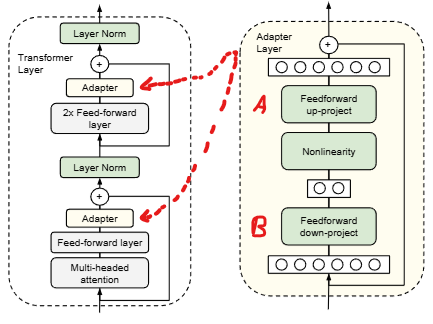

Схема адаптера | [Источник](https://arxiv.org/abs/1902.00751) (без пометок)

Исходные веса $W$ замораживаются; матрицы $A$ и $B$ дообучаются на целевой задаче.

### Экспериментальные результаты адаптеров

Результаты на наборе GLUE (BERT-Large) из работы [Houlsby et al., 2019](https://arxiv.org/abs/1902.00751):

| Метод                 | Параметров на задачу $\downarrow$ | GLUE Score $\uparrow$ |
| :-------------------- | :-------------------------------: | :-------------------: |
| Полное дообучение     | 335M (100%)                       | 80.4                  |
| Адаптер ($r = 8-256$) | $\sim$12M ($\sim$3.6%)            | 80.0                  |
| Адаптер ($r = 64$)    | $\sim$7M ($\sim$2.1%)             | 79.6                  |

<font color='Red'>**Важно:**</font> Адаптеры могут позволить достичь сравнимого с полным дообучением качества, обучая несколько % от всех весов.

**Основной недостаток.** Адаптер встраивается последовательно в вычислительный граф, что увеличивает его глубину. На этапе инференса это приводит к накладным расходам: дополнительному проходу через матрицы $B$ и $A$. Для больших батчей и длинных последовательностей данный эффект становится ощутимым.

### Малоранговая адаптация

<font color='Orange'>**Вопрос:**</font> В чём состоит основной недостаток классических адаптеров?

#### Ответ:

Последовательное встраивание адаптера изменяет архитектуру модели и влечёт за собой накладные расходы на этапе инференса.

Рассмотрим, что происходит при замене нелинейной функции активации тождественным отображением, $\sigma = \mathrm{Id}$:

$$
W^\top x + A \, (B^\top x) = W^\top x + (AB^\top) x = \left(W^\top + AB^\top \right) x.
$$

Полученный слой эквивалентен линейному слою с матрицей весов $W^\top + AB^\top$. По завершении обучения низкоранговую поправку $AB^\top$ можно интегрировать непосредственно в матрицу $W^\top$, полностью устраняя накладные расходы на инференсе.

<font color='Orange'>**Вопрос:**</font> Почему нельзя оптимизировать матрицу $\Delta W = AB^\top$ напрямую, как единый параметр размера $m \times n$?

#### Ответ:

Прямая оптимизация полной матрицы $\Delta W$ потребовала бы $mn$ обучаемых параметров и фактически вернула бы нас к обычному дообучению соответствующего линейного слоя. Разложение $\Delta W = AB^\top$ ограничивает ранг поправки и требует только $r(m+n)$ обучаемых параметров при $r \ll \min(m,n)$.

<font color='Orange'>**Вопрос:**</font> Допустимо ли применять данный подход без нелинейной функции активации $\sigma$?

#### Ответ:

Да. Именно отсутствие нелинейности и лежит в основе метода LoRA. Два последовательных линейных преобразования без нелинейности эквивалентны одному линейному преобразованию. При построении глубоких сетей этот эффект является нежелательным, поэтому между слоями вводятся функции активации. В методе LoRA этот эффект используется намеренно.

Рассмотрим слой вида

$$
\left(W^\top + \Delta W\right) x,
$$

где матрица $\Delta W$ имеет малый ранг $r$. Матрица $W^\top + \Delta W$ отличается от исходной $W^\top$ на малоранговую поправку $\Delta W$; малость ранга обеспечивает малый параметрический бюджет.

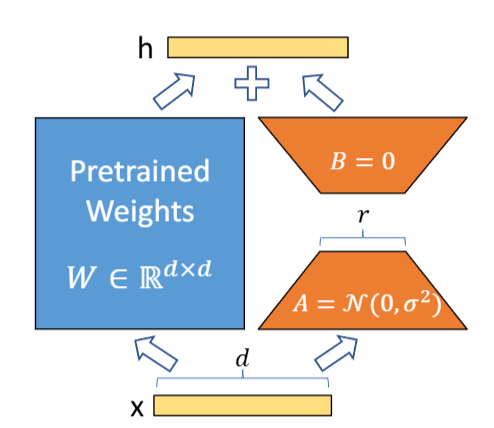

LoRA: схема малорангового адаптера. Синий &ndash; замороженные параметры, оранжевый &ndash; обучаемые  | [Источник](https://arxiv.org/abs/2106.09685)

### Экспериментальные результаты LoRA

Результаты на модели GPT-3 (175B) из оригинальной статьи [Hu et al., 2022](https://arxiv.org/abs/2106.09685):

| Метод                      | Обучаемых параметров $\downarrow$ | WikiSQL (Acc.) $\uparrow$ | SAMSum (Rouge-L) $\uparrow$ |
| -------------------------- | --------------------------------- | ------------------------- | --------------------------- |
| Полное дообучение          | 175B                              | 73.8                      | 44.5                        |
| Адаптер                    | 7M                                | 71.9                      | 44.8                        |
| **LoRA ($r_Q = r_V = 1$)** | **4.7M**                          | **73.4**                  | **45.9**                    |

<font color='Red'>**Важно:**</font> LoRA с $r \in \{4, 8\}$ может не уступать полному дообучению.

### Детали реализации

### Инициализация

Матрица $A$ инициализируется по методу Kaiming Uniform (стандартная инициализация линейного слоя в PyTorch); матрица $B$ инициализируется нулями. Данный подход предложен в оригинальной статье [Hu et al., 2022](https://arxiv.org/abs/2106.09685) и гарантирует $\Delta W = AB^\top = 0$ в начале обучения, то есть модель начинает с точных предобученных весов.

<font color='Red'>**Важно:**</font> Существуют альтернативные схемы инициализации. В частности, LoRA+ [Hayou et al., 2024](https://arxiv.org/abs/2402.12354) инициализирует $A = 0$, $B$ &ndash; случайно и применяет различные скорости обучения к $A$ и $B$. Метод PiSSA [Meng et al., 2024](https://arxiv.org/abs/2404.02948) инициализирует $A$ и $B$ через SVD-разложение матрицы $W$, что ускоряет сходимость.

### Параметризация

Стандартная параметризация имеет вид:

$$
\Delta W = \frac{\alpha}{r}\, AB^\top.
$$

Коэффициент $\alpha$ выбирается следующим образом:

- $\alpha = 2r$ &ndash; исходная статья [Hu et al., 2022](https://arxiv.org/abs/2106.09685); этот выбор стабилизирует эффективную скорость обучения при варьировании $r$;
- $\alpha = \sqrt{r}$ &ndash; метод rsLoRA [Kalajdzievski, 2023](https://arxiv.org/abs/2312.03732); обеспечивает корректное масштабирование норм градиентов при увеличении $r$.

**Назначение коэффициента.** Без множителя $\alpha / r$ варьирование гиперпараметра $r$ потребовало бы повторного подбора скорости обучения. Введение этого коэффициента позволяет использовать фиксированное значение скорости обучения при различных рангах.

### Выбор матриц для адаптации

Не все весовые матрицы модели одинаково значимы для адаптации. Согласно оригинальной статье [Hu et al., 2022](https://arxiv.org/abs/2106.09685) и последующим исследованиям, приведём сводку для архитектуры типа трансформер:

| Матрица | Описание | Рекомендуется? |
|:---|:---|---:|
| $W_Q$ | Запросы в self-attention | Да |
| $W_K$ | Ключи в self-attention | Да (опционально) |
| $W_V$ | Значения в self-attention | Да |
| $W_O$ | Выходная проекция attention | Да |
| $W_\text{up},\, W_\text{down}$ | Слои FFN | Зависит от задачи (эффективно при больших $r$) |
| Embedding, LM head | Входные/выходные эмбеддинги | Как правило, нет |

**Практические рекомендации.**

- *Instruction tuning и диалоговые модели:* адаптации матриц $W_Q, W_K, W_V, W_O$, как правило, достаточно.
- *Domain adaptation:* целесообразно дополнительно включить слои FFN.
- *Задачи на программирование и математику:* рекомендуется адаптировать все проекционные матрицы.
- В качестве начального значения рекомендуется $r = 8$; при $r > 64$ наблюдается убывающая отдача.

## QLoRA

QLoRA &ndash; модификация LoRA, предназначенная для дообучения квантизованных моделей. Метод позволяет дообучать модели с 65 млрд параметров на одном ускорителе с 48 ГБ памяти [Dettmers et al., 2023](https://arxiv.org/abs/2305.14314).

Веса $W$ хранятся в формате 4-bit; матрицы адаптера $A$ и $B$ &ndash; в формате bf16. В ходе прямого прохода $W$ деквантизуется в bf16 "на лету".

## Анализ вычислительной эффективности LoRA

### Экономия вычислительных ресурсов

Сравним число операций для полного дообучения и LoRA применительно к одному линейному слою.

| Операция | Полное дообучение | LoRA | Примечание |
|:---:|:---:|:---:|:---:|
| **Прямой проход** | | | |
| $y = W x$ | $mn$ | $mn$ |  |
| $h = AB^\top x$ |  | $r(m+n)$ | Два умножения с малыми матрицами |
| **Обратный проход &ndash; проброс градиента** | | | |
| $\partial \mathcal{L} / \partial x$ через $W$ | $mn$ | $mn$ | $W$ заморожен, однако градиент через него проходит |
| $\partial \mathcal{L} / \partial x$ через $AB^\top$ |  | $r(m+n)$ |  |
| **Обратный проход &ndash; градиент весов** | | | |
| $\partial \mathcal{L} / \partial W$ | $mn$ |  | $W$ заморожен |
| $$\partial \mathcal{L} / \partial A,\; \partial \mathcal{L} / \partial B$$ |  | $r(m+n)$ |  |
| **Шаг оптимизатора (Adam)** | | | |
| Обновление весов | $mn$ | $r(m+n)$ |  |
| **Итого** | $\mathbf{4mn}$ | $$\mathbf{2mn + 4r(m+n)}$$ |  |

При $r \ll \min(m, n)$ отношение числа операций составляет:

$$
\frac{2mn + 4r(m+n)}{4mn} \approx \frac{1}{2} + \frac{r}{m} + \frac{r}{n} \approx \frac{1}{2}.
$$

**Замечание.** На практике выигрыш в числе операций меньше ожидаемого по двум причинам: прямой проход через $W$ по-прежнему выполняется в полном объёме ($mn$ операций); кроме того, узким местом зачастую является не число операций с плавающей точкой, а пропускная способность памяти (memory bandwidth).

### Экономия памяти

Сравним объём памяти, необходимой для хранения всех компонентов при обучении одного линейного слоя.

| Компонент | Полное дообучение | LoRA | Примечание |
|:---:|:---:|:---:|:---:|
| **Параметры** | | | |
| $W$ | $mn$ | $mn$ | Хранится в обоих случаях |
| $A, B$ |  | $r(m+n)$ | Обучаемый адаптер |
| **Градиенты** | | | |
| $\partial \mathcal{L} / \partial W$ | $mn$ |  | $W$ заморожен |
| $$\partial \mathcal{L} / \partial A,\; \partial \mathcal{L} / \partial B$$ |  | $r(m+n)$ |  |
| **Состояние оптимизатора (Adam)** | | | |
| $\mu_W,\, \nu_W$ | $2mn$ |  | $W$ заморожен |
| $$\mu_A, \mu_B, \nu_A, \nu_B$$ |  | $2r(m+n)$ |  |
| **Итого (параметры + градиенты + оптимизатор)** | $\mathbf{4mn}$ | $$\mathbf{mn + 4r(m+n)}$$ |  |

<font color='Orange'>**Вопрос:**</font> Какой компонент не учтён в приведённой таблице?

#### Ответ:

Не учтены затраты памяти на хранение промежуточных активаций (intermediate activations), необходимых для обратного прохода.

### Активации как доминирующий компонент

В современных моделях для обработки последовательностей затраты памяти на хранение промежуточных активаций зачастую оказываются наибольшими. Введём обозначения: $B$ &ndash; размер батча, $L$ &ndash; длина последовательности, $d$ &ndash; скрытая размерность, $h$ &ndash; число голов внимания. Затраты на активации одного слоя трансформера:

| Активация | Размер |
|:---|---:|
| Вход слоя $x$ | $B \cdot L \cdot d$ |
| Матрицы $Q, K, V$ | $3 \cdot B \cdot L \cdot d$ |
| Матрица внимания (до softmax) | $B \cdot h \cdot L^2$ |
| Матрица внимания (после softmax) | $B \cdot h \cdot L^2$ |
| Промежуточные активации FFN | $B \cdot L \cdot 4d$ |
| **Итого на слой** | $$\approx B \cdot L \cdot (8d + 2hL)$$ |

**Ключевое наблюдение.** Слагаемое $B \cdot h \cdot L^2$ растёт квадратично с длиной последовательности. При $L = 8192$, $B = 4$, $h = 32$ матрицы внимания одного слоя занимают $4 \cdot 32 \cdot 8192^2 \approx 8.6 \times 10^9$ элементов, что в формате float32 составляет около 32 ГБ.

**Принципиальное ограничение LoRA.** LoRA не сокращает затраты памяти на активации: обратный проход по-прежнему проходит через все замороженные слои, и промежуточные активации необходимо хранить. Это является основной причиной того, что практическая экономия памяти при использовании LoRA меньше, чем следует из сравнения итоговых строк таблицы выше.

**Методы снижения затрат на хранение активаций.**

- **Gradient checkpointing.** Активации не сохраняются, а пересчитываются в ходе обратного прохода. Метод даёт экономию памяти порядка $\sqrt{N_\text{layers}}$ при дополнительных вычислительных затратах около 30%.
- **FlashAttention.** Алгоритм вычисления механизма внимания, при котором полная матрица размера $L \times L$ не материализуется в памяти.

### Эффективная размерность

Экспериментально было показано, что LoRA позволяет получать достаточно высокое качество модели после дообучения. В некоторых задачах качество обученной модели оказывается сравнимым с качеством после полного дообучения (Full fine-tune). Но почему оказывается возможным, используя всего % от исходны весов, получать сравнимое с FullFT качество?

**Ключевая идея** [Aghajanyan et al., 2021](https://arxiv.org/abs/2012.13255). Задачи дообучения обладают весьма низкой внутренней размерностью (intrinsic dimension). Несмотря на то, что пространство параметров модели имеет миллиарды измерений, оптимальное решение для прикладной задачи, как правило, лежит в подпространстве значительно меньшей размерности.

**Формальное определение.** Внутренняя размерность $d_{90}$ задачи $\mathcal{T}$ &ndash; это минимальная размерность подпространства, в котором существует решение, достигающее 90% от качества полного дообучения.

**Экспериментальные результаты** [Aghajanyan et al., 2021](https://arxiv.org/abs/2012.13255):

| Задача | Параметров модели | $d_{90}$ |
|:---|:---:|:---:|
| CoLA (синтаксис) | 125M | ~1000 |
| MRPC (парафраз) | 125M | ~200 |
| QQP (семантическая близость) | 125M | ~1000 |
| SST-2 (тональность) | 125M | ~100 |

Примечательно, что для задачи анализа тональности оказывается достаточно 100 обучаемых параметров &ndash; при 125 млн параметров модели &ndash; для достижения 90% от качества полного дообучения.

**Связь с LoRA.** LoRA является одной из практических реализаций данной идеи. В отличие от оригинальной работы, где использовалось случайное подпространство, LoRA выбирает структурированное низкоранговое подпространство для каждой весовой матрицы. Такой выбор более эффективен, поскольку подпространство согласовано со структурой весов модели.

**Содержательная интерпретация.** Предобученная модель обладает обширными общими знаниями. Адаптация к прикладной задаче представляет собой лишь небольшую корректировку: в пространстве весов она может быть сложной, тогда как в пространстве функций &ndash; оказывается простой.

## Другие методы PEFT

Помимо LoRA существует обширный класс методов PEFT. Ниже представлены наиболее значимые из них.

### DoRA (Weight-Decomposed Low-Rank Adaptation)

В отличие от LoRA, которая обновляет матрицу $W$ в виде $W + \Delta W$, DoRA разделяет обновление на два независимых компонента &ndash; направление и величину [Liu et al., 2024](https://arxiv.org/abs/2402.09353):

$$
W' = \frac{W + \Delta W}{\|W + \Delta W\|_c} \cdot \|W\|_c,
$$

где $\|\cdot\|_c$ обозначает вектор норм столбцов, а умножение выполняется поэлементно по столбцам. Компонент величины обучается как отдельный вектор; компонент направления &ndash; посредством стандартного LoRA-адаптера. Метод демонстрирует заметный прирост качества при тех же вычислительных затратах.

### Сравнительный анализ методов PEFT

| Метод             | Обучаемых параметров | Overhead на инференсе  | Рекомендуется для                   |
| :---------------- | :------------------: | :--------------------: | :---------------------------------- |
| Полное дообучение | 100%                 | Нет                    | Большой объём данных и ресурсов     |
| Адаптер           | ~1%                  | Да                     | Архитектуры типа BERT               |
| Prompt Tuning     | <0.1%                | Нет                    | Закрытые модели большого размера    |
| Prefix Tuning     | ~0.1%                | Нет                    | Задачи генерации текста             |
| LoRA              | 0.1&ndash;1%         | Нет (после интеграции) | Универсальное применение            |
| QLoRA             | 0.1&ndash;1%         | Нет                    | Ограниченные вычислительные ресурсы |

**Практическая рекомендация.** В большинстве производственных сценариев оптимальным выбором является LoRA или QLoRA.